## ***Importing Libraries***

In [886]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## ***Loading Data***

In [887]:
train_data = pd.read_excel("Data/Data_Train.xlsx")

In [888]:
test_data = pd.read_excel("Data/Test_set.xlsx")

In [889]:
pd.set_option('display.max_columns', None)

In [890]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [891]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [892]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


## ***Duplicates***

In [893]:
train_data.duplicated().sum()

np.int64(220)

In [894]:
test_data.duplicated().sum()

np.int64(26)

#### ****both the train and test data have duplicate records in them but it is possible in this case so do not remove it****

## ***Missing Values***

In [895]:
train_data.isnull().sum() # only 1 missing value route and total_stops in train data

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

## ***Removing the null values from training data***

In [896]:
train_data.dropna(inplace=True)

In [897]:
print(train_data.isnull().sum())
print("+" * 25)
print(test_data.isnull().sum())

#  ***train and test data have 0 missing values***

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
+++++++++++++++++++++++++
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64


In [898]:
print(train_data.shape)

(10682, 11)


# **EDA and Data Cleaning**

## **1. Data of Journey**

## *Not extracting the year since the data is from 2019 only*

In [899]:
# Convert Date_of_Journey to datetime

train_data['Date_of_Journey'] = pd.to_datetime(
    train_data['Date_of_Journey'], format='%d/%m/%Y'
)

test_data['Date_of_Journey'] = pd.to_datetime(
    test_data['Date_of_Journey'], format='%d/%m/%Y'
)

# Extract day and month from Date_of_Journey

train_data['Journey_Day'] = train_data['Date_of_Journey'].dt.day
train_data['Journey_Month'] = train_data['Date_of_Journey'].dt.month

test_data['Journey_Day'] = test_data['Date_of_Journey'].dt.day
test_data['Journey_Month'] = test_data['Date_of_Journey'].dt.month

# Drop Date_of_Journey as it is now redundant

train_data.drop(['Date_of_Journey'], axis= 1, inplace= True)
test_data.drop(['Date_of_Journey'], axis= 1, inplace= True)

In [900]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


## ***2. Departure Time and 3. Arrival Time***

In [901]:
train_data['Dep_Time'] = pd.to_datetime(train_data['Dep_Time'])
train_data['Arrival_Time'] = pd.to_datetime(train_data['Arrival_Time'])

test_data['Dep_Time'] = pd.to_datetime(test_data['Dep_Time'])
test_data['Arrival_Time'] = pd.to_datetime(test_data['Arrival_Time'])

In [902]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-07-16 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-07-16 05:50:00,2026-07-16 13:15:00,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-07-16 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-07-16 18:05:00,2026-07-16 23:30:00,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-07-16 16:50:00,2026-07-16 21:35:00,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2026-07-16 19:55:00,2026-07-16 22:25:00,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,2026-07-16 20:45:00,2026-07-16 23:20:00,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,2026-07-16 08:20:00,2026-07-16 11:20:00,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,2026-07-16 11:30:00,2026-07-16 14:10:00,2h 40m,non-stop,No info,12648,1,3


## ***Extract hour and minute from Dep_Time and Arrival_Time***

In [903]:
train_data['Dep_Hour'] = train_data['Dep_Time'].dt.hour
train_data['Dep_Minute'] = train_data['Dep_Time'].dt.minute

train_data['Arrival_Hour'] = train_data['Arrival_Time'].dt.hour
train_data['Arrival_Minute'] = train_data['Arrival_Time'].dt.minute

test_data['Dep_Hour'] = test_data['Dep_Time'].dt.hour
test_data['Dep_Minute'] = test_data['Dep_Time'].dt.minute

test_data['Arrival_Hour'] = test_data['Arrival_Time'].dt.hour
test_data['Arrival_Minute'] = test_data['Arrival_Time'].dt.minute

# Drop Dep_Time and Arrival_Time as they are now redundant

train_data.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)
test_data.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)

In [904]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10


## ***4. Duration***

In [905]:
# Handling Duration feature

def convert_duration(duration):
    duration = duration.split()
    hours = 0
    minutes = 0
    for d in duration:
        if 'h' in d:
            hours = int(d[:-1])
        elif 'm' in d:
            minutes = int(d[:-1])
    return hours * 60 + minutes

train_data['Duration'] = train_data['Duration'].apply(convert_duration)
test_data['Duration'] = test_data['Duration'].apply(convert_duration)

In [906]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10


## ***5. Creating a new feature "Journey Day" (monday = 0, tuesday = 1, ...... sunday = 6)***

In [907]:
# Journey Day of Week

train_data['Journey_Day_of_Week'] = train_data.apply(
    lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'], 
                              day=row['Journey_Day']).dayofweek, axis=1)

test_data['Journey_Day_of_Week'] = test_data.apply(
    lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'], 
                              day=row['Journey_Day']).dayofweek, axis=1)

In [908]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4


In [909]:
train_data['Journey_Day_of_Week'].value_counts()

Journey_Day_of_Week
2    2079
0    1849
3    1832
5    1670
6    1474
4     909
1     869
Name: count, dtype: int64

## ***6. Creating a new feature - whether the day of journey was weekend or not***

In [910]:
# Is Weekend

train_data['Is_Weekend'] = train_data['Journey_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)
test_data['Is_Weekend'] = test_data['Journey_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

In [911]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0


## ***7. Creating a new feature Departure part of the day - morning, afternoon, evening, night***

In [912]:
def part_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

## ***Departure Part of the Day***

In [913]:
train_data['Dep_Part_of_Day'] = train_data['Dep_Hour'].apply(part_of_day)
test_data['Dep_Part_of_Day'] = test_data['Dep_Hour'].apply(part_of_day)

## ***Dep_Part_of_Day feature distribution***

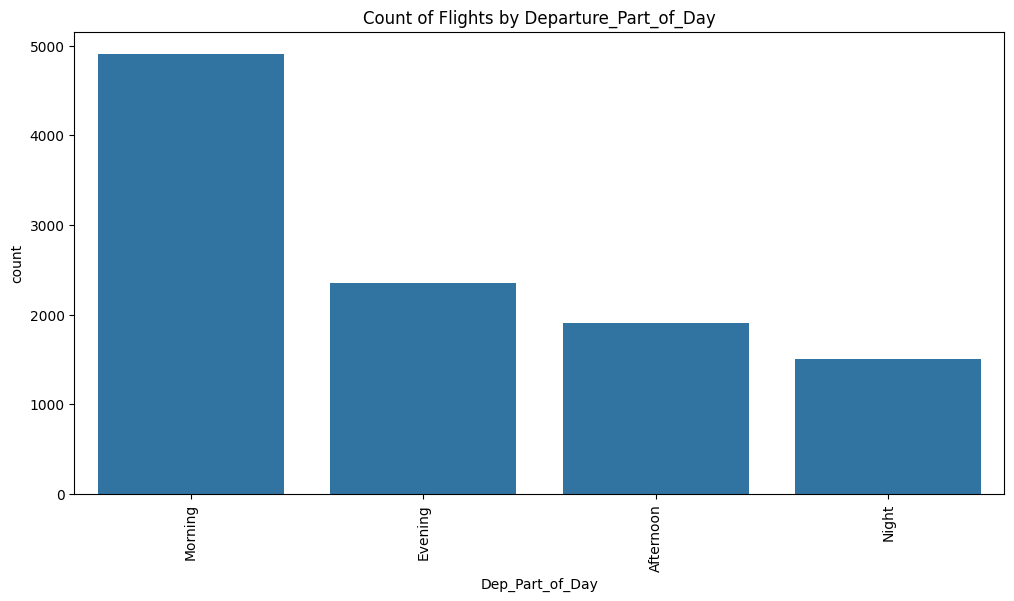

In [914]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Dep_Part_of_Day', order=train_data['Dep_Part_of_Day'].value_counts().index)
plt.title('Count of Flights by Departure_Part_of_Day')
plt.xticks(rotation=90)
plt.show()

## ***Dep_Part_of_Day feature dependence on Price***

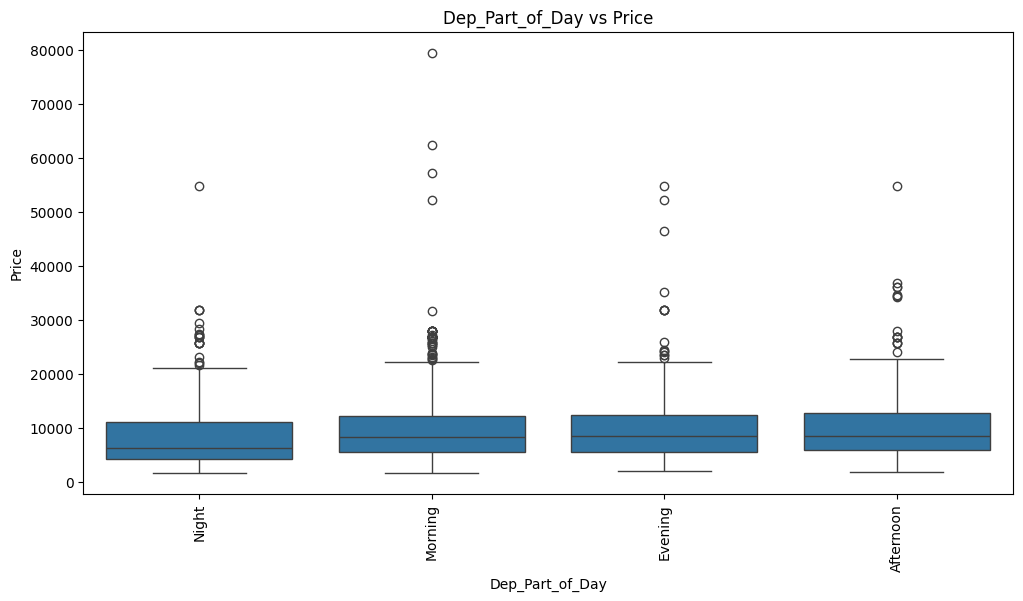

In [915]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Dep_Part_of_Day', y='Price',
            order=train_data.groupby('Dep_Part_of_Day')['Price'].median().sort_values().index)
plt.title('Dep_Part_of_Day vs Price')
plt.xticks(rotation=90)
plt.show()

In [916]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning


## ***8. Number of Routes***

In [917]:
train_data['Num_Routes'] = train_data['Route'].apply(lambda x: len(x.split('→')))
test_data['Num_Routes'] = test_data['Route'].apply(lambda x: len(x.split('→')))

In [918]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2


## ***9. Arrival part of the day***

In [919]:
train_data['Arrival_Part_of_Day'] = train_data['Arrival_Hour'].apply(part_of_day)
test_data['Arrival_Part_of_Day'] = test_data['Arrival_Hour'].apply(part_of_day)

In [920]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_of_Day
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2,Night
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4,Afternoon
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4,Night
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3,Night
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2,Night
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2,Night
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2,Morning
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2,Afternoon


## ***Arrival_Part_of_Day feature distribution***

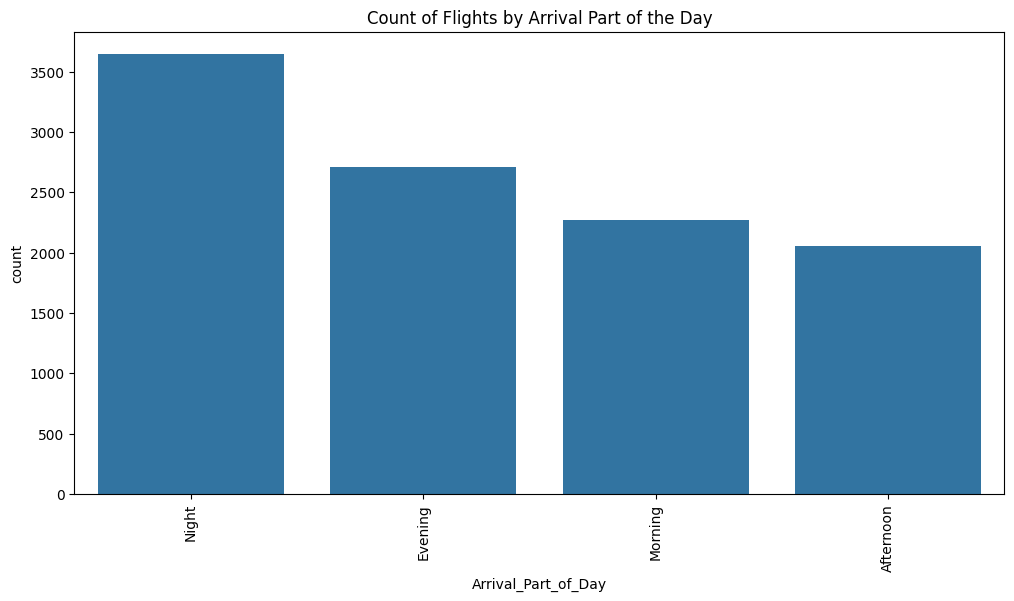

In [921]:
plt.figure(figsize= (12, 6))
sns.countplot(data= train_data, x = 'Arrival_Part_of_Day', order= train_data['Arrival_Part_of_Day'].value_counts().index)
plt.title('Count of Flights by Arrival Part of the Day')
plt.xticks(rotation= 90)
plt.show()

## ***Arrival_Part_of_Day feature dependence on Price***

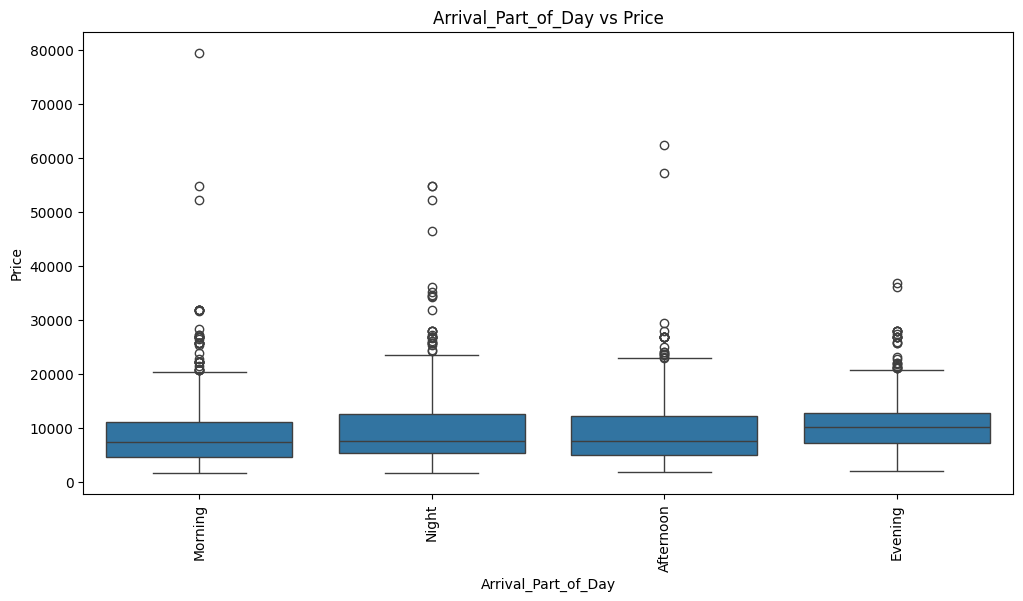

In [922]:
plt.figure(figsize= (12, 6))
sns.boxplot(data= train_data, x = 'Arrival_Part_of_Day', y='Price', order= train_data.groupby('Arrival_Part_of_Day')
            ['Price'].median().sort_values().index)
plt.title('Arrival_Part_of_Day vs Price')
plt.xticks(rotation= 90)
plt.show()

## ***10. Flight Duration in hours***

In [923]:
train_data['Duration_Hours']= train_data['Duration'] / 60
test_data['Duration_Hours']= test_data['Duration'] / 60

In [924]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2,Afternoon,2.666667


## ***Dropping unnecessary features now***

In [925]:
train_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'], axis=1, inplace=True)
test_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'], axis=1, inplace=True)

In [926]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667


In [929]:
train_data.corr(numeric_only=True)

,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Num_Routes,Duration_Hours
Price,1.000000,-0.153774,-0.103643,0.051570,0.020275,0.603897,0.506480
Journey_Day,-0.153774,1.000000,-0.038359,-0.091245,-0.104187,-0.009451,-0.022439
Journey_Month,-0.103643,-0.038359,1.000000,-0.083345,-0.013189,0.054383,0.014836
Journey_Day_of_Week,0.051570,-0.091245,-0.083345,1.000000,0.815513,-0.036750,-0.012729
Is_Weekend,0.020275,-0.104187,-0.013189,0.815513,1.000000,-0.019548,-0.004143
Num_Routes,0.603897,-0.009451,0.054383,-0.036750,-0.019548,1.000000,0.738071
Duration_Hours,0.506480,-0.022439,0.014836,-0.012729,-0.004143,0.738071,1.000000


## ***11. Airline***

In [ ]:
train_data['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

## ***Airline feature distribution***

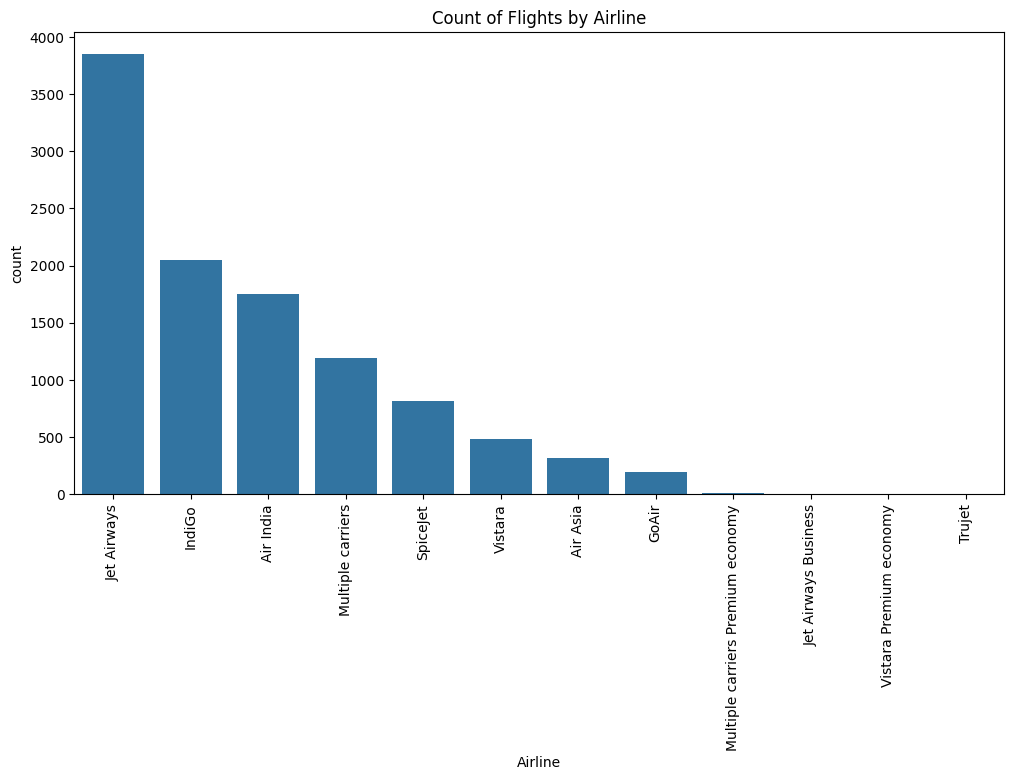

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Airline', order=train_data['Airline'].value_counts().index)
plt.title('Count of Flights by Airline')
plt.xticks(rotation=90)
plt.show()

## ***Airline feature dependence on Price***

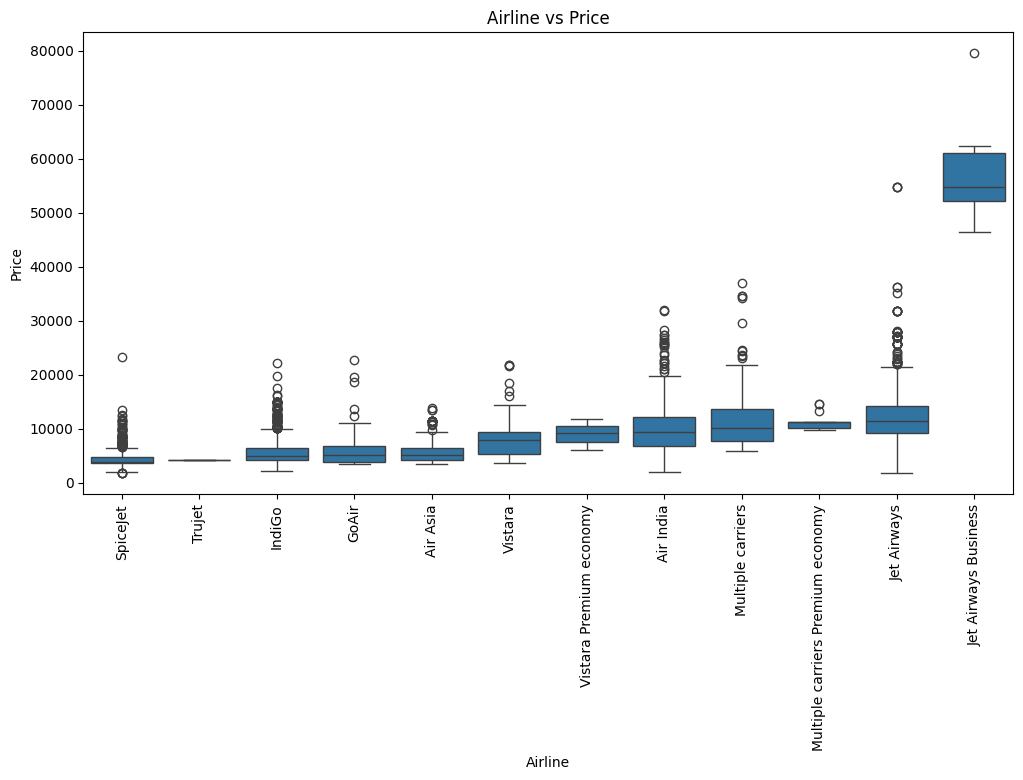

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Airline', y='Price', order=train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()

## ***Merging specified categories in the 'Airline' feature***

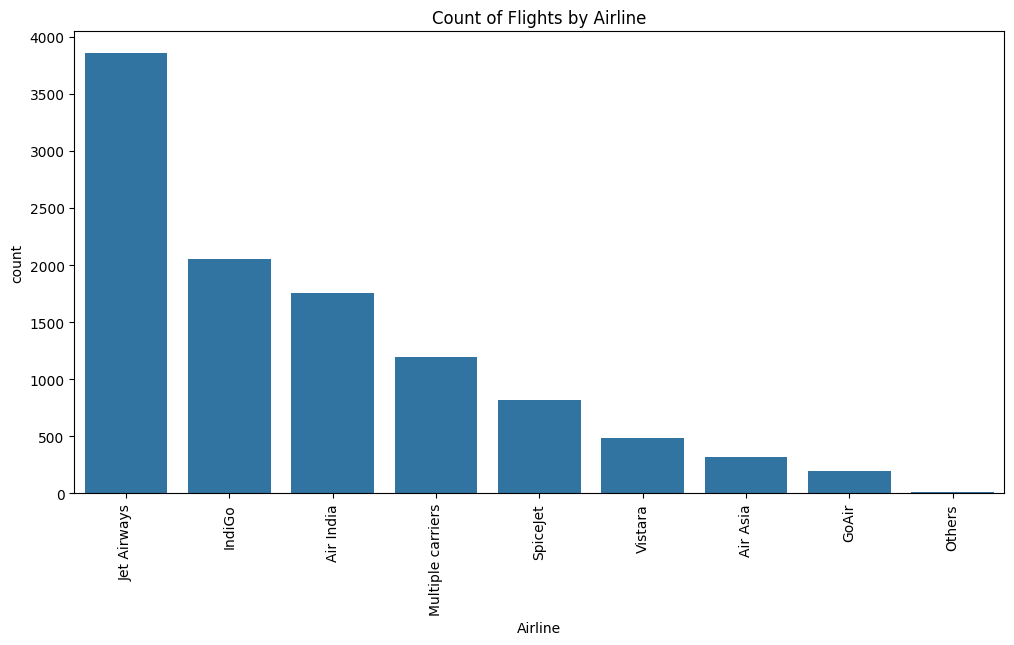

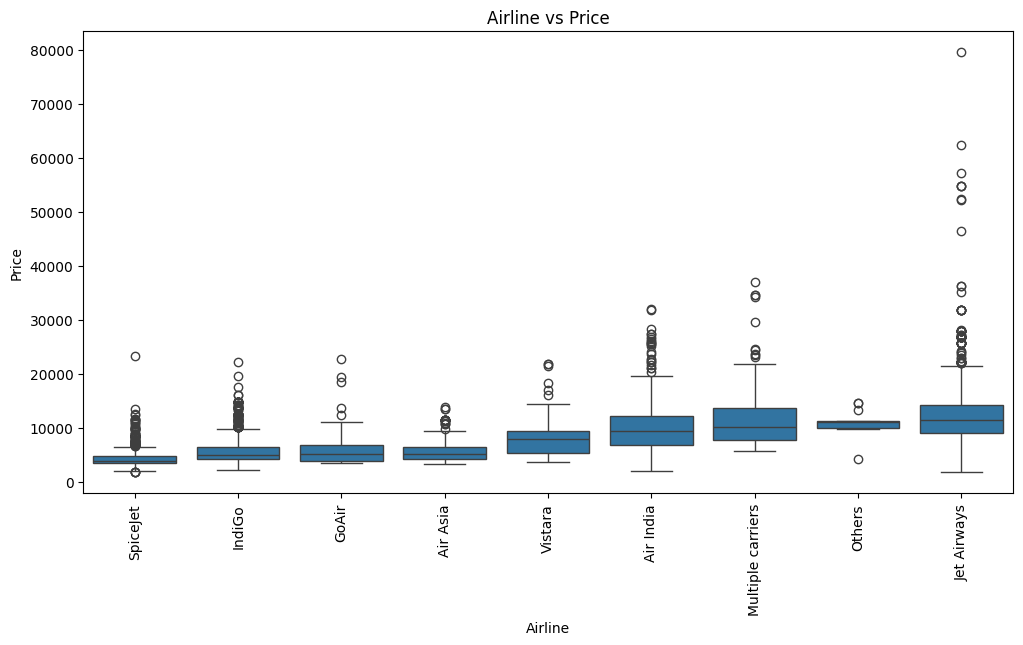

In [ ]:
train_data['Airline'] = train_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})

test_data['Airline'] = test_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})

# Re-plotting the updated Airline feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Airline', order=train_data['Airline'].value_counts().index)
plt.title('Count of Flights by Airline')
plt.xticks(rotation=90)
plt.show()

# Re-plotting the updated Airline feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Airline',
    y='Price',
    order=train_data.groupby('Airline')['Price'].median().sort_values().index
)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()

## ***Plotting Source distribution***

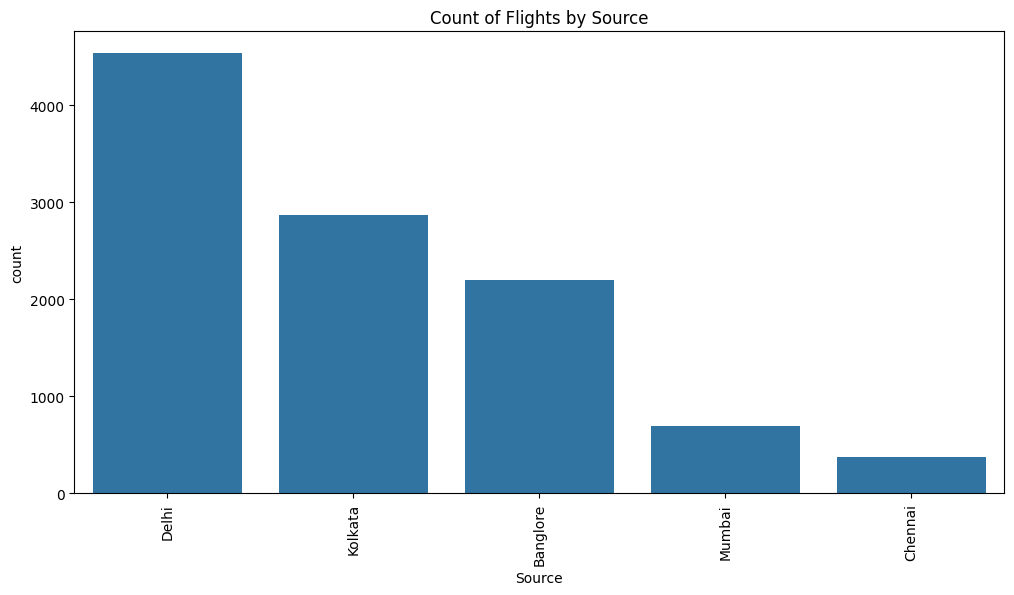

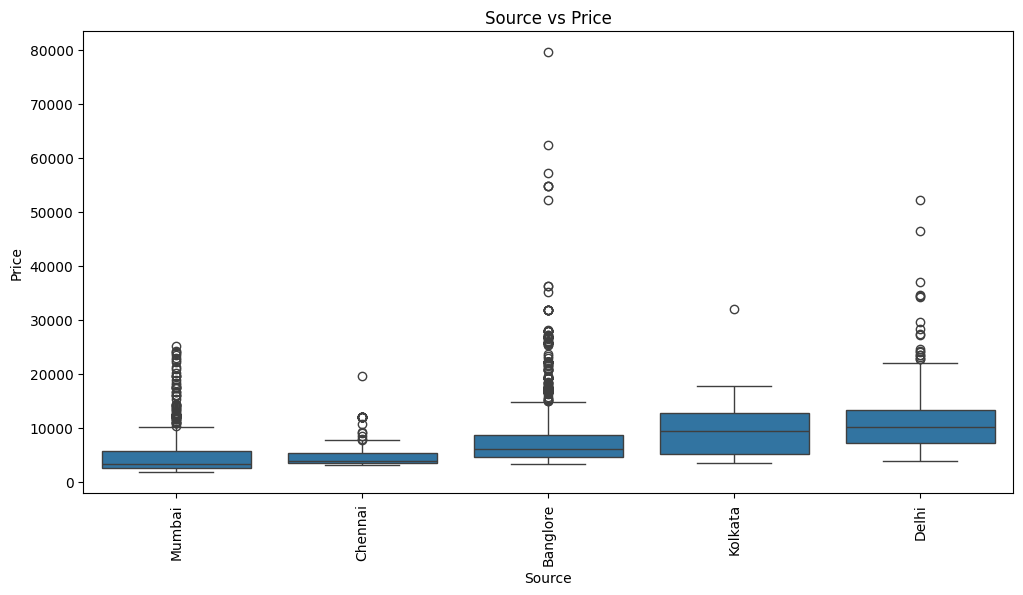

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Source', order=train_data['Source'].value_counts().index)
plt.title('Count of Flights by Source')
plt.xticks(rotation=90)
plt.show()

# Source feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Source', y='Price',
            order=train_data.groupby('Source')['Price'].median().sort_values().index)
plt.title('Source vs Price')
plt.xticks(rotation=90)
plt.show()
     

## ***---- 12. Source ----***

### ***Plotting Source distribution***

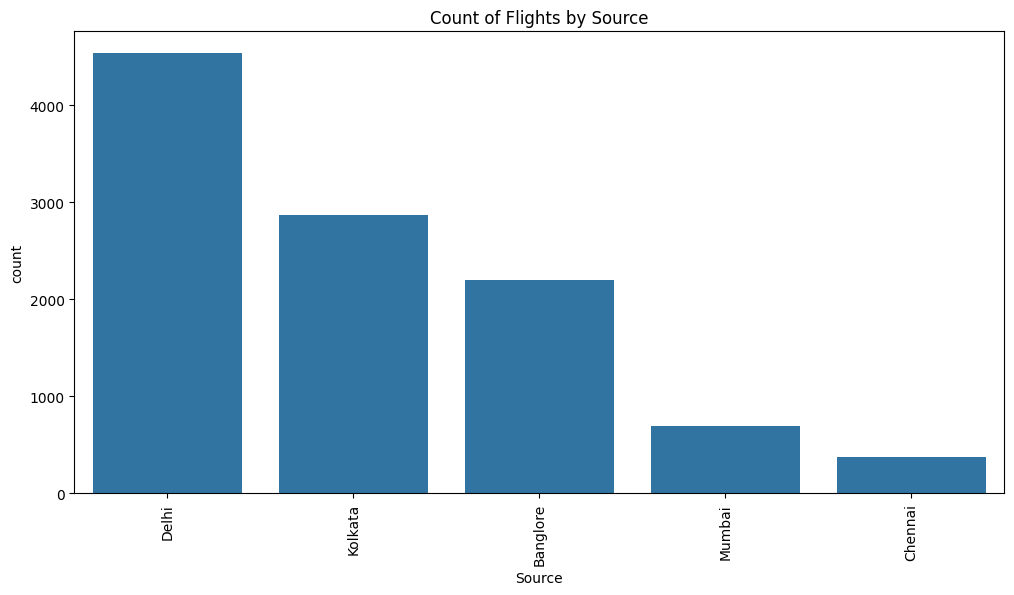

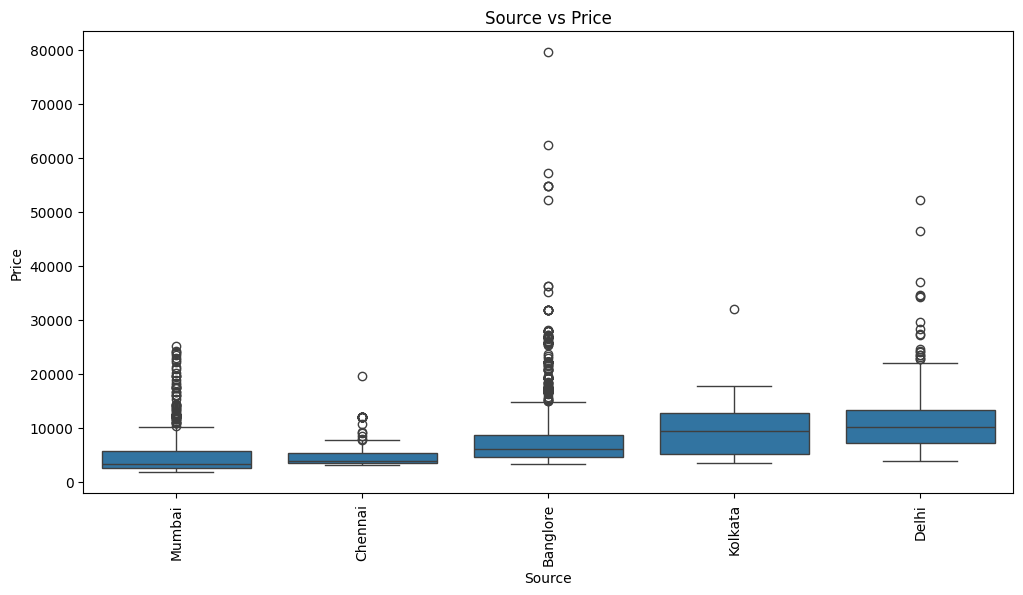

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Source', order=train_data['Source'].value_counts().index)
plt.title('Count of Flights by Source')
plt.xticks(rotation=90)
plt.show()

# Source feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Source',
    y='Price',
    order=train_data.groupby('Source')['Price'].median().sort_values().index
)
plt.title('Source vs Price')
plt.xticks(rotation=90)
plt.show()


## ***---- 13. Destination ----***

### ***Plotting Destination distribution***

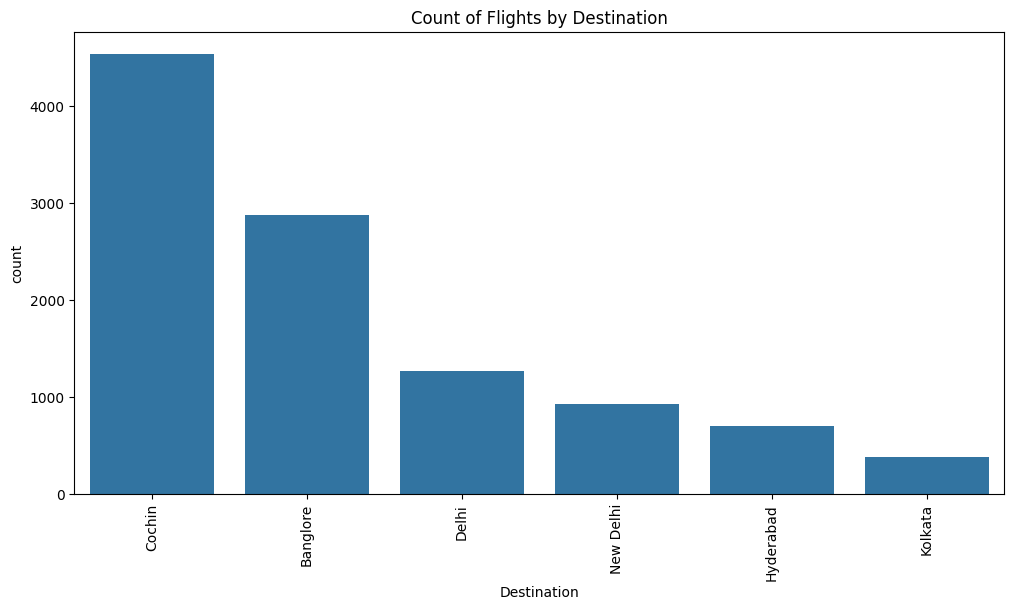

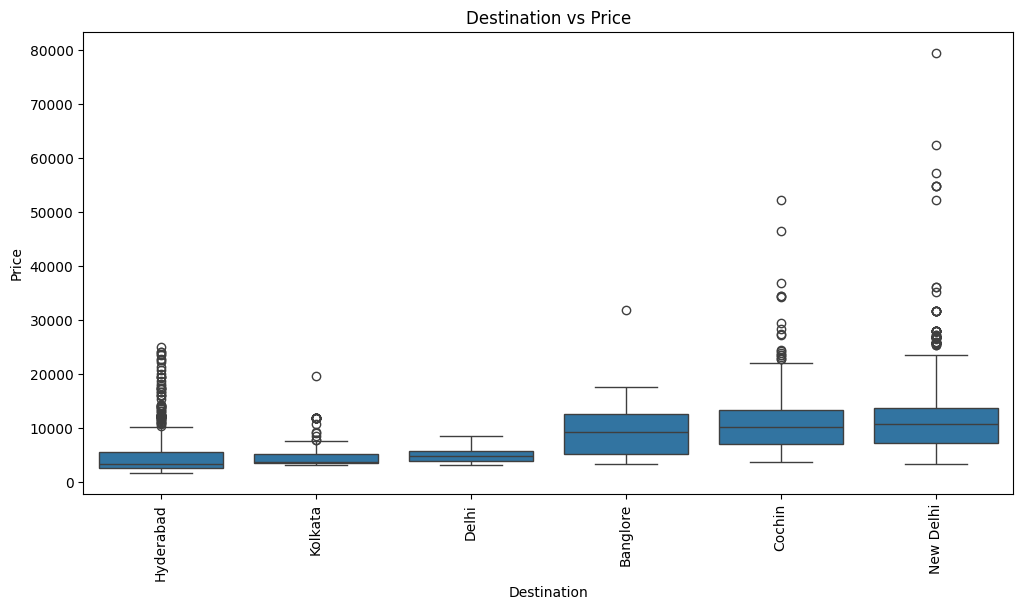

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Destination', order=train_data['Destination'].value_counts().index)
plt.title('Count of Flights by Destination')
plt.xticks(rotation=90)
plt.show()

# Destination feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Destination',
    y='Price',
    order=train_data.groupby('Destination')['Price'].median().sort_values().index
)
plt.title('Destination vs Price')
plt.xticks(rotation=90)
plt.show()
     

## ***14. Creating a new feautre as Route popularity***

In [ ]:
# Route Popularity - 1) combining the route using source - destination (source to destination)

train_data['Route'] = train_data['Source'] + '-' + train_data['Destination']
test_data['Route'] = test_data['Source'] + '-' + test_data['Destination']

In [ ]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_of_Day,Duration_Hours,Route
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333,Banglore-New Delhi
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,Kolkata-Banglore
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000,Delhi-Cochin
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667,Kolkata-Banglore
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,Banglore-New Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000,Kolkata-Banglore
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333,Kolkata-Banglore
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,Banglore-Delhi
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,Banglore-New Delhi


## ***checking the counts for route popularity***

In [ ]:
route_popularity = train_data['Route'].value_counts()
route_popularity

Route
Delhi-Cochin          4536
Kolkata-Banglore      2871
Banglore-Delhi        1265
Banglore-New Delhi     932
Mumbai-Hyderabad       697
Chennai-Kolkata        381
Name: count, dtype: int64

## ***Mapping these routes***

In [ ]:
train_data['Route_Popularity'] = train_data['Route'].map(route_popularity)
test_data['Route_Popularity'] = test_data['Route'].map(route_popularity)

In [ ]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_of_Day,Duration_Hours,Route,Route_Popularity
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333,Banglore-New Delhi,932
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,Kolkata-Banglore,2871
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000,Delhi-Cochin,4536
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667,Kolkata-Banglore,2871
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,Banglore-New Delhi,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000,Kolkata-Banglore,2871
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333,Kolkata-Banglore,2871
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,Banglore-Delhi,1265
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,Banglore-New Delhi,932
